In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("brfss_clean_2020_2024.csv")
df_summary = pd.read_csv("brfss_group_summary_modeled.csv")

print("Individual data shape:", df.shape)
print("Group summary shape:", df_summary.shape)
print("Columns in summary:", df_summary.columns.tolist())

Individual data shape: (1622499, 14)
Group summary shape: (4953, 10)
Columns in summary: ['age_group', 'sex', 'education', 'income_group', 'race_group', 'obesity_rate', 'n', 'reliable', 'obesity_rate_smoothed', 'obesity_rate_modeled']


In [2]:
race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

group_cols = ["age_group", "sex", "education", "income_group", "race_group"]

def cell_stats(group):
    p = np.average(group["obese"], weights=group["_LLCPWT_adjusted"])
    variance = p * (1 - p)
    n_obese = group["obese"].sum()
    n_non_obese = len(group) - n_obese
    brier_computable = (n_obese > 0) and (n_non_obese > 0)
    return pd.Series({
        "cell_variance": variance,
        "n_obese": n_obese,
        "n_non_obese": n_non_obese,
        "brier_computable": int(brier_computable)
    })

cell_stats_df = (
    df.groupby(group_cols)
    .apply(cell_stats)
    .reset_index()
)

# Merge with group summary
df_summary_updated = df_summary.merge(cell_stats_df, on=group_cols)

print("Shape:", df_summary_updated.shape)
print("\nBrier computable breakdown:")
print(f"  Computable: {df_summary_updated['brier_computable'].sum()}")
print(f"  Not computable (will produce NaN): {(df_summary_updated['brier_computable']==0).sum()}")

print("\nNot computable by race group:")
not_comp = df_summary_updated[df_summary_updated["brier_computable"]==0]
print(not_comp["race_group"].value_counts())

print("\nNot computable by reliability:")
print(f"  Sparse (n<30): {(not_comp['reliable']==0).sum()}")
print(f"  Reliable (n>=30): {(not_comp['reliable']==1).sum()}")

Shape: (4953, 14)

Brier computable breakdown:
  Computable: 4534.0
  Not computable (will produce NaN): 419

Not computable by race group:
race_group
NHOPI                154
Asian                119
AIAN                  66
Other/Multiracial     32
Hispanic              28
NH-Black              19
NH-White               1
Name: count, dtype: int64

Not computable by reliability:
  Sparse (n<30): 418
  Reliable (n>=30): 1


In [3]:
# Save updated summary with variance and brier flag
df_summary_updated.to_csv("brfss_group_summary_modeled.csv", index=False)
print("Updated brfss_group_summary_modeled.csv with cell_variance and brier_computable columns")

print("\nCell variance distribution:")
print(f"  Mean: {df_summary_updated['cell_variance'].mean():.4f}")
print(f"  Min:  {df_summary_updated['cell_variance'].min():.4f}")
print(f"  Max:  {df_summary_updated['cell_variance'].max():.4f}")

print("\nCell variance by reliability:")
print(f"  Reliable cells mean variance: {df_summary_updated[df_summary_updated['reliable']==1]['cell_variance'].mean():.4f}")
print(f"  Sparse cells mean variance:   {df_summary_updated[df_summary_updated['reliable']==0]['cell_variance'].mean():.4f}")

print("\nCells safe for Brier computation by race:")
safe = df_summary_updated[df_summary_updated["brier_computable"]==1]
print(safe.groupby("race_group")["brier_computable"].count().sort_values())

print("\nColumns in updated file:")
print(df_summary_updated.columns.tolist())

Updated brfss_group_summary_modeled.csv with cell_variance and brier_computable columns

Cell variance distribution:
  Mean: 0.1731
  Min:  0.0000
  Max:  0.2500

Cell variance by reliability:
  Reliable cells mean variance: 0.2054
  Sparse cells mean variance:   0.1277

Cells safe for Brier computation by race:
race_group
NHOPI                505
Asian                592
AIAN                 639
Other/Multiracial    680
Hispanic             693
NH-Black             698
NH-White             727
Name: brier_computable, dtype: int64

Columns in updated file:
['age_group', 'sex', 'education', 'income_group', 'race_group', 'obesity_rate', 'n', 'reliable', 'obesity_rate_smoothed', 'obesity_rate_modeled', 'cell_variance', 'n_obese', 'n_non_obese', 'brier_computable']


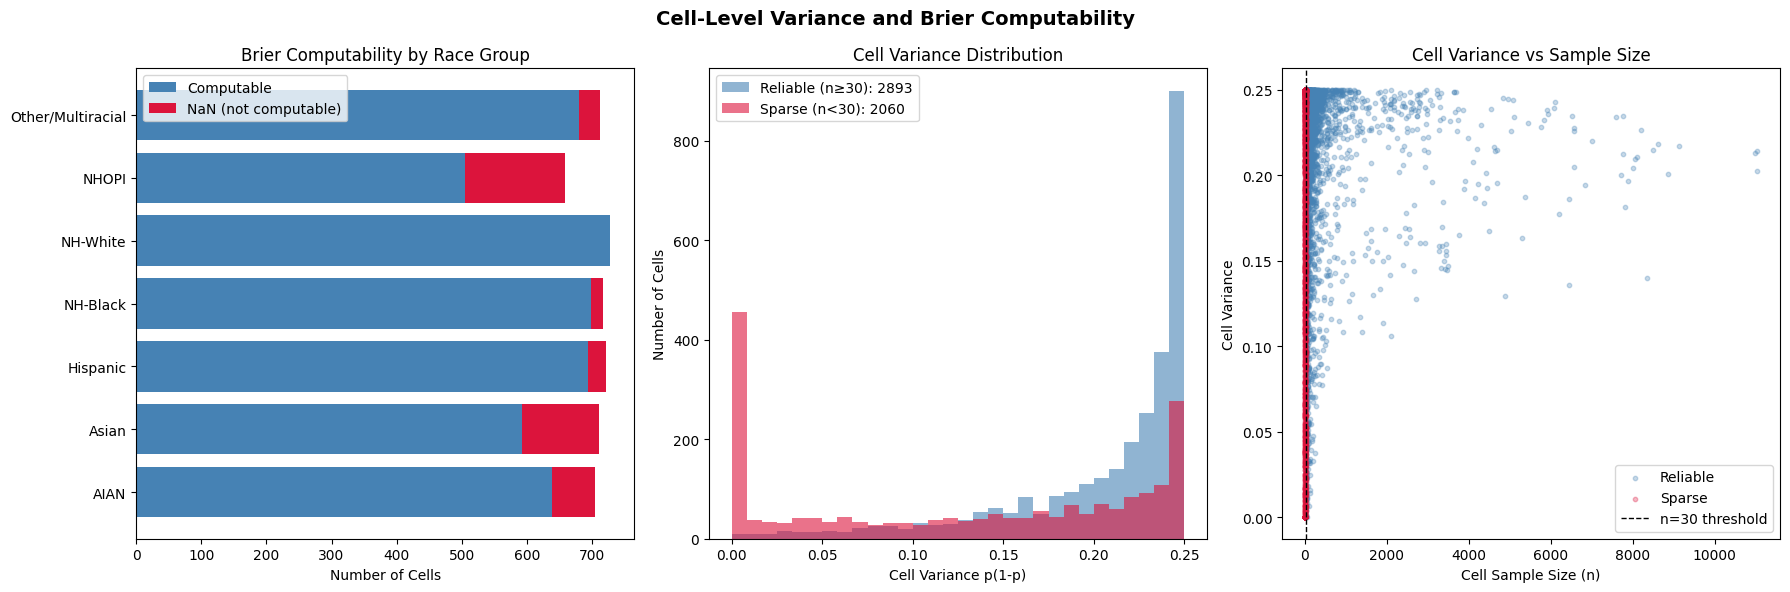

saved brfss_cell_variance_plots.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Cell-Level Variance and Brier Computability", fontsize=14, fontweight="bold")

# Plot 1 — Brier computable by race
ax = axes[0]
race_counts = df_summary_updated.groupby("race_group")["brier_computable"].agg(
    computable=lambda x: (x==1).sum(),
    not_computable=lambda x: (x==0).sum()
).reset_index()
ax.barh(race_counts["race_group"], race_counts["computable"], 
        color="steelblue", label="Computable")
ax.barh(race_counts["race_group"], race_counts["not_computable"],
        left=race_counts["computable"], color="crimson", label="NaN (not computable)")
ax.set_xlabel("Number of Cells")
ax.set_title("Brier Computability by Race Group")
ax.legend()

# Plot 2 — Cell variance distribution
ax = axes[1]
reliable = df_summary_updated[df_summary_updated["reliable"]==1]["cell_variance"]
sparse = df_summary_updated[df_summary_updated["reliable"]==0]["cell_variance"]
ax.hist(reliable, bins=30, alpha=0.6, color="steelblue", label=f"Reliable (n≥30): {len(reliable)}")
ax.hist(sparse, bins=30, alpha=0.6, color="crimson", label=f"Sparse (n<30): {len(sparse)}")
ax.set_xlabel("Cell Variance p(1-p)")
ax.set_ylabel("Number of Cells")
ax.set_title("Cell Variance Distribution")
ax.legend()

# Plot 3 — Variance vs n
ax = axes[2]
ax.scatter(df_summary_updated[df_summary_updated["reliable"]==1]["n"],
           df_summary_updated[df_summary_updated["reliable"]==1]["cell_variance"],
           alpha=0.3, color="steelblue", s=10, label="Reliable")
ax.scatter(df_summary_updated[df_summary_updated["reliable"]==0]["n"],
           df_summary_updated[df_summary_updated["reliable"]==0]["cell_variance"],
           alpha=0.3, color="crimson", s=10, label="Sparse")
ax.axvline(30, color="black", linestyle="--", linewidth=1, label="n=30 threshold")
ax.set_xlabel("Cell Sample Size (n)")
ax.set_ylabel("Cell Variance")
ax.set_title("Cell Variance vs Sample Size")
ax.legend()

plt.tight_layout()
plt.savefig("brfss_cell_variance_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_cell_variance_plots.png")

## Cell-Level Variance and Brier Computability

### What This Notebook Does
Identifies which demographic cells will produce Brier NaN during model evaluation
and provides cell-level variance estimates for each demographic cell.

### Key Findings

**419 cells have zero outcome variance.**
419 cells have 0% or 100% obesity rates, meaning they contain only one class
and Brier score cannot be computed for these cells. 418 of these 419 cells
have fewer than 30 respondents — this is a data sparsity issue, not a model failure.
The one reliable cell with zero variance is Asian males aged 75-79 with college
degrees earning 200k+ — a plausible demographic with genuinely low obesity rates
but a sample too small to observe any obese individuals.

**NHOPI, Asian, and AIAN are most affected.**
NHOPI has 154 non-computable cells, Asian has 119, AIAN has 66.
These groups have the fewest BRFSS respondents nationally and are
disproportionately represented in sparse cells.

**Reliable cells have meaningful variance.**
Reliable cells (n≥30) have mean variance of 0.2054 — close to the maximum
of 0.25. Sparse cells have mean variance of 0.1277, pulled down by the
419 zero-variance cells. The 2,893 reliable cells contain genuine outcome
variation and are appropriate for Brier score computation.

**4,534 cells are safe for Brier computation.**
Filtering to `brier_computable == 1` gives 4,534 valid cells — 91.5% of
all demographic cells.

### New Columns Added to brfss_group_summary_modeled.csv
- `cell_variance` — p(1-p) for each cell, range 0 to 0.25
- `n_obese` — count of obese respondents in cell
- `n_non_obese` — count of non-obese respondents in cell
- `brier_computable` — 1 if both classes present, 0 if Brier will return NaN